Cell 1 — Load API Key

This cell loads your Etherscan API key from the .env file so the notebook can use it without exposing the key in the code. It checks that the key is loaded correctly and prints only the first few characters for confirmation.


In [4]:
from dotenv import load_dotenv
import os

# look for .env in the parent folder of notebooks/
load_dotenv("../.env")

API_KEY = os.getenv("ETHERSCAN_API_KEY")
print("Loaded key:", API_KEY[:6] + "..." if API_KEY else None)

Loaded key: R7NWRK...


Cell 2 — Test Etherscan Connection

This cell sends a simple test request to the Etherscan V2 API to make sure the API key, URL, and connection all work properly. If the response is “OK”, it means we can safely continue to fetch real on-chain data.

In [5]:
import requests

url = "https://api.etherscan.io/v2/api"

params = {
    "chainid": 1,            # Ethereum mainnet
    "module": "account",
    "action": "balance",     # super simple test
    "address": "0x88e6A0c2dDD26FEEb64F039a2c41296FcB3f5640",  # any valid address works
    "tag": "latest",
    "apikey": API_KEY,       # 🔐 secure key from .env
}

response = requests.get(url, params=params).json()

print(response)

{'status': '1', 'message': 'OK', 'result': '0'}


Cell 3 — Fetch Uniswap V3 Swap Logs

This cell retrieves actual swap event logs from the Uniswap V3 USDC/WETH pool on Ethereum. It queries the blockchain for a specific block range and stores the returned logs in a DataFrame for analysis.

In [10]:
import requests
import pandas as pd

POOL_ADDRESS = "0x88e6A0c2dDD26FEEb64F039a2c41296FcB3f5640"  # Uniswap V3 USDC/WETH 0.05%

# ✅ Correct Uniswap V3 Swap event topic
SWAP_TOPIC0 = "0xc42079f94a6350d7e6235f29174924f928cc2ac818eb64fed8004e115fbcca67"

url = "https://api.etherscan.io/v2/api"

params = {
    "chainid": 1,
    "module": "logs",
    "action": "getLogs",
    "address": POOL_ADDRESS,
    "fromBlock": 18000000,   # good active range; you can change later
    "toBlock": 18100000,
    "topic0": SWAP_TOPIC0,
    "page": 1,
    "offset": 1000,
    "apikey": API_KEY,
}

resp = requests.get(url, params=params).json()
print("Status:", resp.get("status"), "| Message:", resp.get("message"))

logs = resp.get("result", [])
print("Number of logs:", len(logs))

df = pd.DataFrame(logs)
df.head()

Status: 1 | Message: OK
Number of logs: 1000


,address,topics,data,blockNumber,blockHash,timeStamp,gasPrice,gasUsed,logIndex,transactionHash,transactionIndex
0,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0xffffffffffffffffffffffffffffffffffffffffffff...,0x112a881,0xd5ca78be6c6b42cf929074f502cef676372c26f8d0ba...,0x64ea269b,0x59357e7b1,0x3559a,0xbd,0x8187139f2cf5e1d2b0a817f2951f0592fccc43dabf71...,0x21
1,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0x00000000000000000000000000000000000000000000...,0x112a882,0x5b94c39ad7eecbf043f62a4a76c5abee87195207df98...,0x64ea26a7,0x5760a9dc4,0x377b4,0xad,0x29ec08dc5eed0e1cd411b29c52607661155087ffa107...,0x2b
2,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0x00000000000000000000000000000000000000000000...,0x112a88d,0xf68f282d1fc1e116c64443efd6ef0a0e1048bf21017d...,0x64ea272b,0x46c7cfe00,0x2ea32,0xe7,0xcf7b968094b30c7a7e1c88003e8496c621b73ef284e4...,0x5e
3,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0x00000000000000000000000000000000000000000000...,0x112a88f,0x943f087b63585553db2d5a45f7550e41557405aa9ab4...,0x64ea2743,0x43c08918f,0x31ab2,0x109,0x070379239598fdeaed5cf8910f87135c55783fb75778...,0x75
4,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0x00000000000000000000000000000000000000000000...,0x112a89d,0x6ac7fe3575dfb18c5dc8b746acd0d472e78230a30ea1...,0x64ea27eb,0x490b2770e,0x3024a,0xe9,0xb3bb64bb54d6465a80bfa0fe396868c08c40595b84e9...,0x4d


Cell 4 — Save Logs to CSV

This cell saves the fetched logs as a CSV file in the project directory. This allows us to reuse the data later for cleaning, visualization, and machine learning without needing to call the API every time.

In [11]:
import os

output_path = "../data/raw/uniswap_v3_usdc_weth_swap_logs_sample.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df.to_csv(output_path, index=False)

print("Saved logs to:", output_path)

Saved logs to: ../data/raw/uniswap_v3_usdc_weth_swap_logs_sample.csv


Cell 5 — Convert hex fields to readable numbers  

In this cell we convert `blockNumber` and `timeStamp` from hex strings (e.g. `0x64ea269b`) into normal integers, and then turn the timestamp into a human-readable datetime column. This makes it easier to understand when each swap happened.

In [13]:
import pandas as pd

# Work on a copy of the original logs
logs_clean = df.copy()

# Convert blockNumber from hex string (e.g. '0xabcdef') to integer
logs_clean["blockNumber_int"] = logs_clean["blockNumber"].apply(
    lambda x: int(x, 16) if isinstance(x, str) and x.startswith("0x") else int(x)
)

# Convert timeStamp from hex string to integer seconds, then to datetime
if "timeStamp" in logs_clean.columns:
    logs_clean["timeStamp_int"] = logs_clean["timeStamp"].apply(
        lambda x: int(x, 16) if isinstance(x, str) and x.startswith("0x") else int(x)
    )
    logs_clean["timeStamp_dt"] = pd.to_datetime(logs_clean["timeStamp_int"], unit="s")

logs_clean[["blockNumber", "blockNumber_int", "timeStamp", "timeStamp_int", "timeStamp_dt"]].head()

,blockNumber,blockNumber_int,timeStamp,timeStamp_int,timeStamp_dt
0,0x112a881,18000001,0x64ea269b,1693066907,2023-08-26 16:21:47
1,0x112a882,18000002,0x64ea26a7,1693066919,2023-08-26 16:21:59
2,0x112a88d,18000013,0x64ea272b,1693067051,2023-08-26 16:24:11
3,0x112a88f,18000015,0x64ea2743,1693067075,2023-08-26 16:24:35
4,0x112a89d,18000029,0x64ea27eb,1693067243,2023-08-26 16:27:23


Cell 6 — Decode Uniswap V3 swap event fields  

In this cell we extract more meaningful information from each log.  
We decode the `topics` field to get the `sender` and `recipient` addresses, and we break down the hex-encoded `data` field into numeric values: `amount0`, `amount1`, `sqrtPriceX96`, `liquidity`, and `tick`.  
These new columns will be the main features for our later analysis and anomaly detection.

In [14]:
import numpy as np
import ast

# Helper: convert 256-bit hex to signed integer (for amount0, amount1, tick)
def hex_to_signed_int(hex_str, bits=256):
    value = int(hex_str, 16)
    if value >= 2 ** (bits - 1):
        value -= 2 ** bits
    return value

def decode_swap_row(row):
    # --- 1) Handle topics: extract sender and recipient ---

    topics = row["topics"]

    # If topics was saved as a string (e.g. after CSV), try to parse it back to a list
    if isinstance(topics, str):
        try:
            topics = ast.literal_eval(topics)
        except Exception:
            # If parsing fails, just return NaNs for safety
            return pd.Series({
                "sender": np.nan,
                "recipient": np.nan,
                "amount0": np.nan,
                "amount1": np.nan,
                "sqrtPriceX96": np.nan,
                "liquidity": np.nan,
                "tick": np.nan,
            })

    # topics[1] = sender, topics[2] = recipient
    sender = "0x" + topics[1][-40:]
    recipient = "0x" + topics[2][-40:]

    # --- 2) Handle data: split into 5 x 32-byte segments ---

    data_hex = row["data"]
    if isinstance(data_hex, str) and data_hex.startswith("0x"):
        data_hex = data_hex[2:]  # remove '0x'

    # Each 32-byte word = 64 hex characters
    chunks = [data_hex[i:i+64] for i in range(0, len(data_hex), 64)]

    if len(chunks) < 5:
        # If something is off, return NaNs but keep sender/recipient
        return pd.Series({
            "sender": sender,
            "recipient": recipient,
            "amount0": np.nan,
            "amount1": np.nan,
            "sqrtPriceX96": np.nan,
            "liquidity": np.nan,
            "tick": np.nan,
        })

    # Order for Uniswap V3 Swap:
    # amount0, amount1, sqrtPriceX96, liquidity, tick
    amount0 = hex_to_signed_int(chunks[0])
    amount1 = hex_to_signed_int(chunks[1])
    sqrtPriceX96 = int(chunks[2], 16)
    liquidity = int(chunks[3], 16)
    tick = hex_to_signed_int(chunks[4])  # stored as signed int

    return pd.Series({
        "sender": sender,
        "recipient": recipient,
        "amount0": amount0,
        "amount1": amount1,
        "sqrtPriceX96": sqrtPriceX96,
        "liquidity": liquidity,
        "tick": tick,
    })

# Apply the decoder to each row and join with logs_clean
decoded = logs_clean.apply(decode_swap_row, axis=1)
logs_clean = pd.concat([logs_clean, decoded], axis=1)

logs_clean[["sender", "recipient", "amount0", "amount1", "sqrtPriceX96", "liquidity", "tick"]].head()

,sender,recipient,amount0,amount1,sqrtPriceX96,liquidity,tick
0,0xdef1c0ded9bec7f1a1670819833240f027b25eff,0xb4eae88d1643e172518dde0ef213c20628798c65,-112691264,68325951804594637,1950377674162784547402475521943836,42650691009184698025,202234
1,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0xa66cdad5facbcbf74d9b60dcc8034c2a485e63ff,1075000000,-651132330540292128,1950376464615720204913290619496759,42650691009184698025,202234
2,0xe592427a0aece92de3edee1f18e0157c05861564,0xdef171fe48cf0115b1d80b88dc8eab59176fee57,4950000000,-2998226821761004806,1950370895092782394767185122868363,42650691009184698025,202234
3,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,500000000,-302850241935162707,1950370332516476647311649558107430,42650691009184698025,202234
4,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x81a460ea6fd96a73d5672f1f4aa684697d4b44cc,5000000000,-3028492810232294025,1950364706771269126652095168779662,42650691009184698025,202234


Cell 7 — Save cleaned swap data  

In this cell we save the decoded and cleaned Uniswap V3 swap logs to a processed CSV file.  
This lets us reuse the dataset later without having to call the API or redo all the decoding steps.

In [15]:
import os

# Path for processed data
processed_path = "../data/processed/uniswap_v3_usdc_weth_swaps_processed.csv"

# Create folder if it doesn't exist
os.makedirs(os.path.dirname(processed_path), exist_ok=True)

# Save the cleaned and decoded DataFrame
logs_clean.to_csv(processed_path, index=False)

print("Saved processed data to:", processed_path)

Saved processed data to: ../data/processed/uniswap_v3_usdc_weth_swaps_processed.csv


Cell 8 — Basic plots for initial analysis 
 
Here we create a few simple visualizations of the swap data.  
We look at the distribution of trade sizes and how swap activity changes over time, which will be useful for understanding normal behaviour before applying anomaly detection.

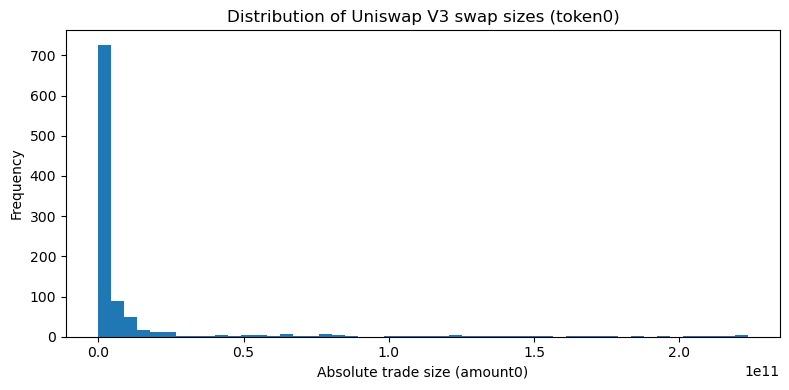

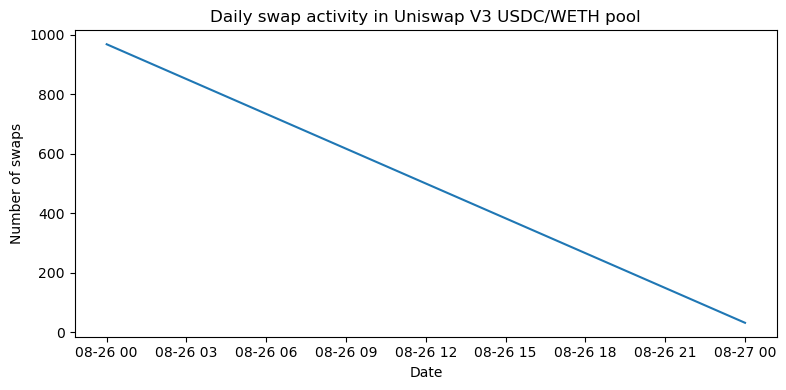

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Make a copy to avoid warnings
plot_df = logs_clean.copy()

# 1) Create an absolute trade size column (using token0)
plot_df["abs_amount0"] = plot_df["amount0"].abs()

# Drop NaNs
plot_df = plot_df.dropna(subset=["abs_amount0", "timeStamp_dt"])

# Optionally clip very large values for nicer plots (e.g., 99th percentile)
cutoff = plot_df["abs_amount0"].quantile(0.99)
plot_df_small = plot_df[plot_df["abs_amount0"] <= cutoff]

# --- Plot 1: Histogram of trade sizes (amount0) ---

plt.figure(figsize=(8, 4))
plt.hist(plot_df_small["abs_amount0"], bins=50)
plt.xlabel("Absolute trade size (amount0)")
plt.ylabel("Frequency")
plt.title("Distribution of Uniswap V3 swap sizes (token0)")
plt.tight_layout()
plt.show()

# --- Plot 2: Number of swaps over time (per day) ---

# Group by day
swaps_per_day = plot_df.set_index("timeStamp_dt").resample("D")["transactionHash"].count()

plt.figure(figsize=(8, 4))
plt.plot(swaps_per_day.index, swaps_per_day.values)
plt.xlabel("Date")
plt.ylabel("Number of swaps")
plt.title("Daily swap activity in Uniswap V3 USDC/WETH pool")
plt.tight_layout()
plt.show()